# Real vs Simulated Data — Clustering Comparison

This notebook compares the clustering pipeline on **Real**, **Simulated**, and **Combined** (Real + Simulated) data from the 3W dataset.

## Goal
Verify whether the consensus clustering pipeline generalizes across data sources and whether mixing real and simulated data produces meaningful clusters.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline

from ThreeWToolkit.dataset import ParquetDataset
from ThreeWToolkit.core.base_dataset import ParquetDatasetConfig, EventPrefixEnum
from ThreeWToolkit.core.base_clustering import (
    InstanceQualityConfig,
    ResamplingConfig,
    TimeSeriesScalingConfig,
    DistanceMatrixConfig,
    HierarchicalClusteringConfig,
    MultivariateConsensusConfig,
)
from ThreeWToolkit.core.enums import DistanceMetricEnum
from ThreeWToolkit.clustering import (
    InstanceQualityFilter,
    TimeSeriesResampler,
    TimeSeriesScaler,
    DistanceComputer,
    HierarchicalClusterer,
    MultivariateConsensus,
    compute_dba_centroid,
)
from ThreeWToolkit.data_visualization import (
    DataQualityHeatmap,
    ClusterSizeCurvePlot,
    SelectionHeatmapPlot,
    ClusteringOverlayPlot,
    RankedDistancePlot,
)

In [2]:
DATASET_PATH = "../../dataset"
TARGET_CLASS = 2
TARGET_VARS = ["P-PDG", "P-TPT", "T-TPT", "P-MON-CKP", "T-JUS-CKP"]
CONSENSUS_THRESHOLD = 0.4

## Reusable Analysis Pipeline

The function below encapsulates the full workflow for a given data source:

1. **Data Quality** — heatmap of NaN + frozen ratios before any filtering
2. **Univariate Processing** — quality filter → resample → scale → DTW → hierarchical clustering
3. **Variable Exclusion** — drop variables with too few surviving instances or per manual list
4. **Multivariate Consensus** — intersect per-variable cluster memberships across thresholds
5. **Visualization** — stability curves, selection heatmap, overlay plots, ranked distances

Running it three times (Real / Simulated / Combined) shows how pipeline behavior changes across data sources.

In [3]:
def run_analysis_pipeline(
    data_map: dict,
    title_prefix: str,
    exclude_vars: list[str] | None = None,
    threshold: float = CONSENSUS_THRESHOLD,
) -> None:
    """Run the full clustering pipeline on a data map and display all visualizations.

    Args:
        data_map: ``{variable: [array, ...]}`` from ``ParquetDataset.load_instances_by_variable()``.
        title_prefix: Label used in all plot titles (e.g. "REAL", "SIMULATED").
        exclude_vars: Variables to skip explicitly (manual exclusion after inspection).
        threshold: Consensus distance threshold for overlay and ranked distance plots.
    """
    exclude_vars = set(exclude_vars or [])

    # Data quality overview (before any filtering)
    instance_labels = [str(i) for i in range(max(len(v) for v in data_map.values()))]
    viz = DataQualityHeatmap.from_data_map(
        data_map,
        variables=TARGET_VARS,
        title=f"{title_prefix} — Data Quality (NaN + Frozen Ratio)",
    )
    fig, _ = viz.plot()
    plt.show()

    # Univariate processing
    trained_models, valid_indices_map, cleaned_data_map = {}, {}, {}

    for var in TARGET_VARS:
        if var not in data_map:
            print(f"  {var}: not found in data_map — skipped")
            continue
        if var in exclude_vars:
            print(f"  {var}: excluded")
            continue

        series_list = data_map[var]
        print(f"  Processing {var}...", end=" ", flush=True)
        try:
            qc = InstanceQualityFilter(InstanceQualityConfig(max_nan_ratio=0.2, max_frozen_ratio=0.95))
            X_clean = qc.fit_transform(series_list)

            if len(X_clean) == 0:
                print("skipped (all instances removed by QC)")
                continue

            pipe = Pipeline([
                ("resample", TimeSeriesResampler(ResamplingConfig(step_size=100, step_method="slice"))),
                ("scaler",   TimeSeriesScaler(TimeSeriesScalingConfig())),
                ("dtw",      DistanceComputer(DistanceMatrixConfig(metric=DistanceMetricEnum.DTW, n_jobs=-1))),
                ("clusterer", HierarchicalClusterer(HierarchicalClusteringConfig())),
            ])
            pipe.fit(X_clean)

            trained_models[var] = pipe.named_steps["clusterer"]
            valid_indices_map[var] = qc.kept_indices_

            resampled = pipe.named_steps["resample"].transform(X_clean)
            cleaned_data_map[var] = pipe.named_steps["scaler"].transform(resampled)

            print(f"kept {len(qc.kept_indices_)} instances")
        except Exception as e:
            print(f"error: {e}")

    valid_vars = list(trained_models)
    if not valid_vars:
        print("  No variables remaining — pipeline aborted.")
        return

    print(f"\n  Variables for consensus ({len(valid_vars)}): {valid_vars}")

    # Multivariate consensus
    consensus = MultivariateConsensus(MultivariateConsensusConfig(
        min_threshold=0.1, max_threshold=1.0, threshold_step=0.1,
    ))
    consensus.fit(trained_models, valid_indices_map=valid_indices_map)

    selected_global = consensus.get_selected_indices_at_threshold(threshold)
    print(f"  Consensus selected {len(selected_global)} instances at threshold {threshold}")

    # Visualization

    # Cluster stability curves
    for var in valid_vars:
        thresholds = np.arange(0.1, 1.1, 0.1).tolist()
        counts = {t: len(trained_models[var].find_main_cluster_indices(t)) for t in thresholds}
        viz = ClusterSizeCurvePlot(counts, title=f"{title_prefix} — Cluster Stability: {var}")
        fig, _ = viz.plot()
        plt.show()

    # Selection heatmap
    viz = SelectionHeatmapPlot(
        consensus.selection_mask_,
        consensus.thresholds_analyzed_,
        title=f"{title_prefix} — Instance Selection Heatmap",
    )
    fig, _ = viz.plot()
    plt.show()

    # Overlay + centroid per variable
    for var in valid_vars:
        local_mapping = valid_indices_map[var]
        series_data = cleaned_data_map[var]
        local_selection = [local_mapping.index(g) for g in selected_global if g in local_mapping]
        centroid = compute_dba_centroid(series_data, local_selection) if local_selection else None
        viz = ClusteringOverlayPlot(
            series_data, local_selection, centroid=centroid,
            title=f"{title_prefix} — Overlay: {var} (threshold={threshold})",
        )
        fig, _ = viz.plot()
        plt.show()

    # Ranked distance per variable
    for var in valid_vars:
        model = trained_models[var]
        local_mapping = valid_indices_map[var]
        local_selection = [local_mapping.index(g) for g in selected_global if g in local_mapping]
        local_univariate = model.find_main_cluster_indices(threshold)
        viz = RankedDistancePlot(
            model.distance_matrix_normalized_,
            local_selection,
            univariate_indices=local_univariate,
            instance_labels=local_mapping,
            title=f"{title_prefix} — Ranked Distances: {var} (threshold={threshold})",
        )
        fig, _ = viz.plot()
        plt.show()

## Analysis 1: Real Data

Load only real well events (`WELL` prefix) for class 2. `P-MON-CKP` is manually excluded — it retains too few instances after quality filtering to produce a reliable cluster.

[ParquetDataset] Dataset found at ../../dataset
[ParquetDataset] Validating dataset integrity...
[ParquetDataset] Dataset integrity check passed!
Real: 22 instances


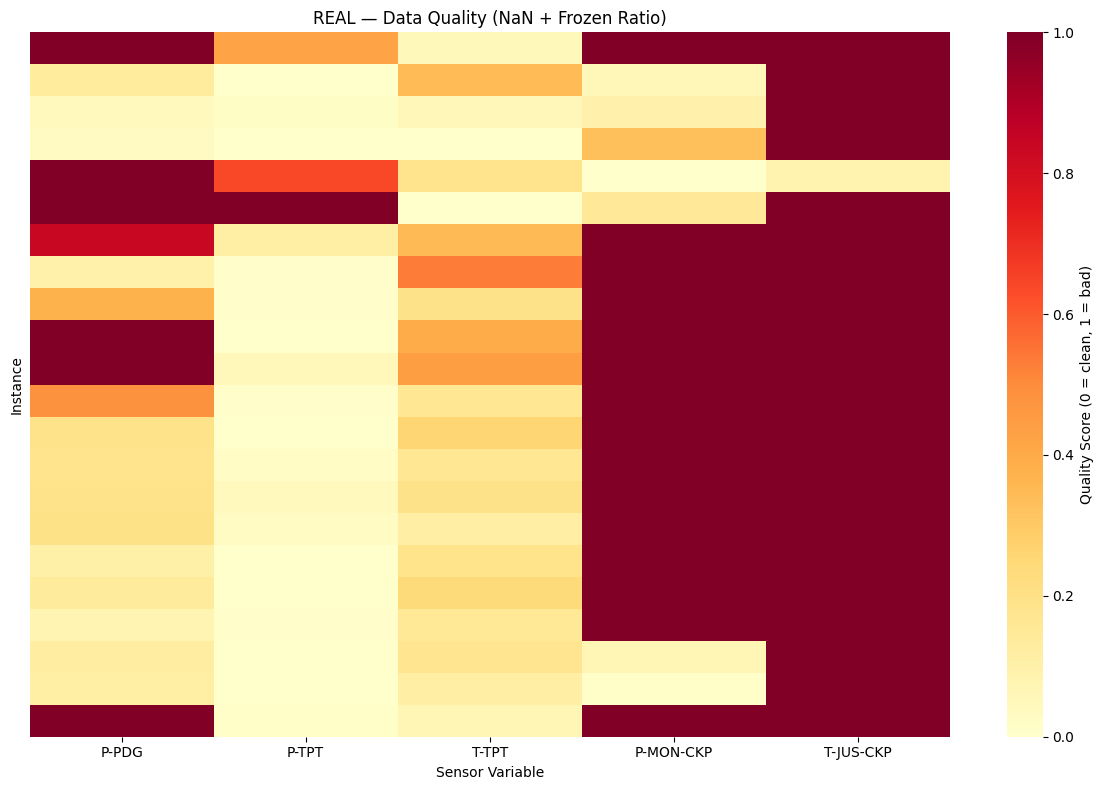

  Processing P-PDG... kept 16 instances
  Processing P-TPT... kept 21 instances
  Processing T-TPT... kept 22 instances
  P-MON-CKP: excluded
  Processing T-JUS-CKP... error: The number of observations cannot be determined on an empty distance matrix.

  Variables for consensus (3): ['P-PDG', 'P-TPT', 'T-TPT']
  Consensus selected 12 instances at threshold 0.4


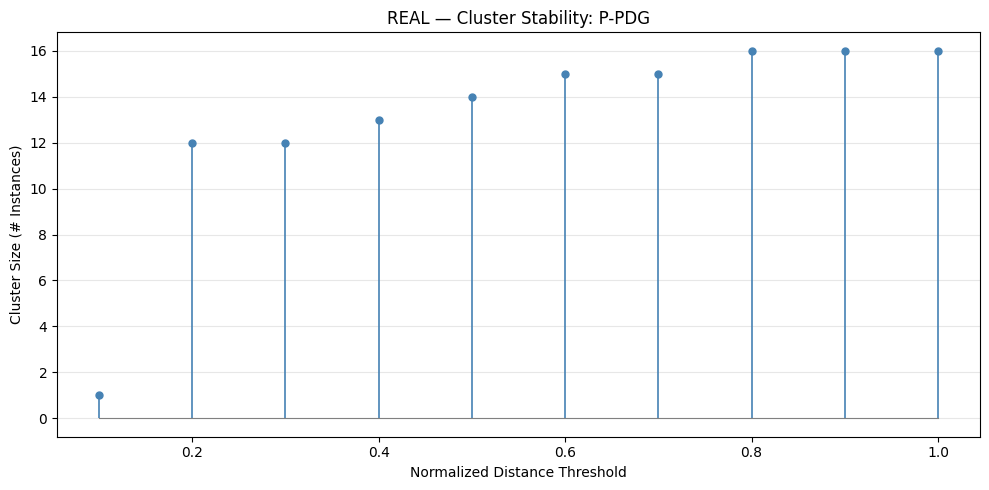

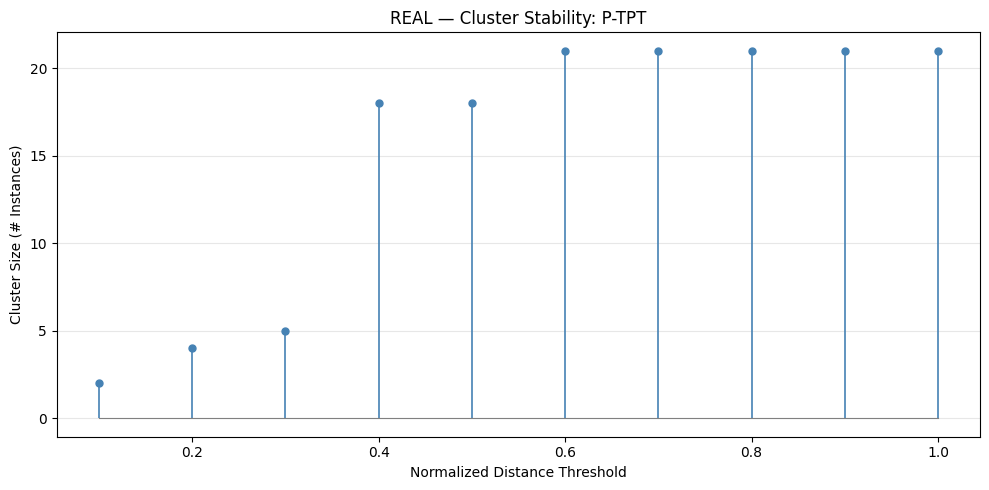

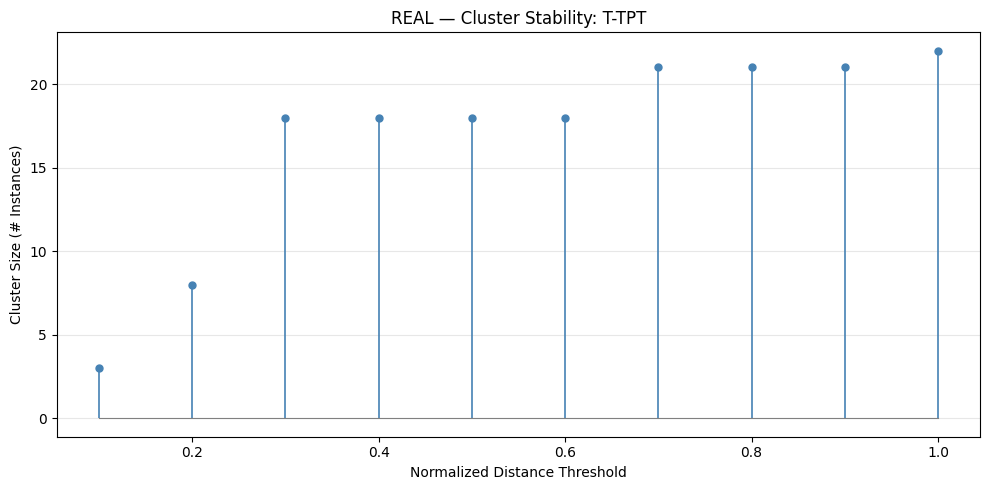

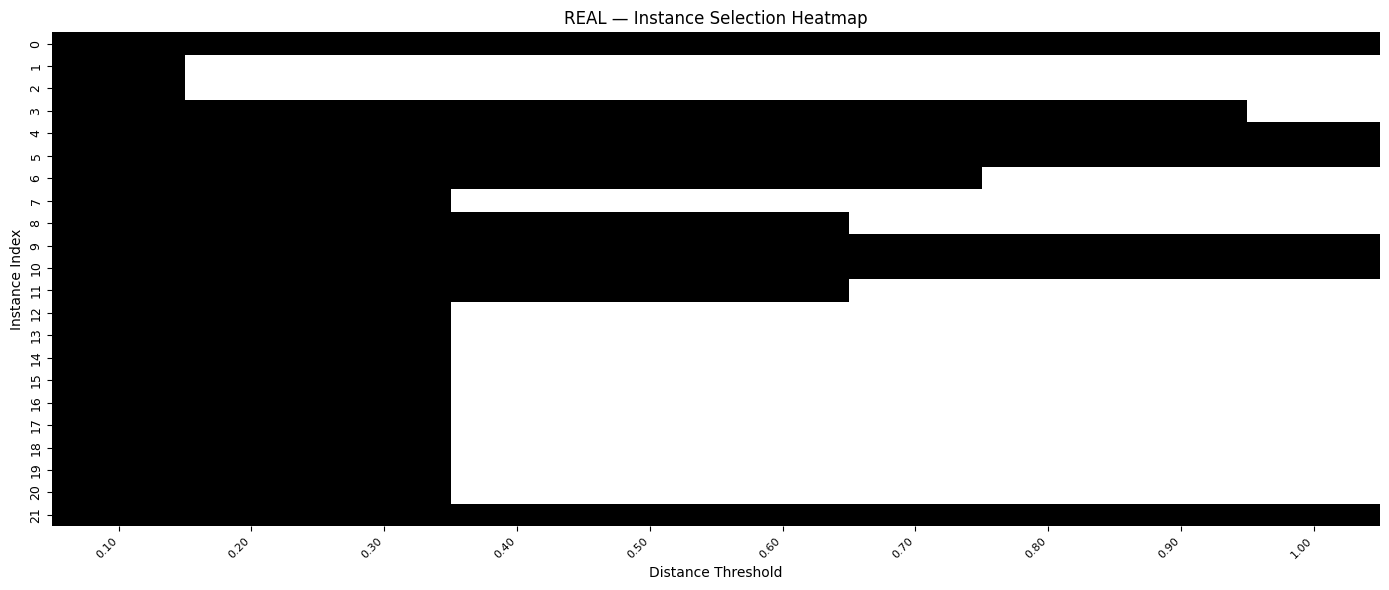

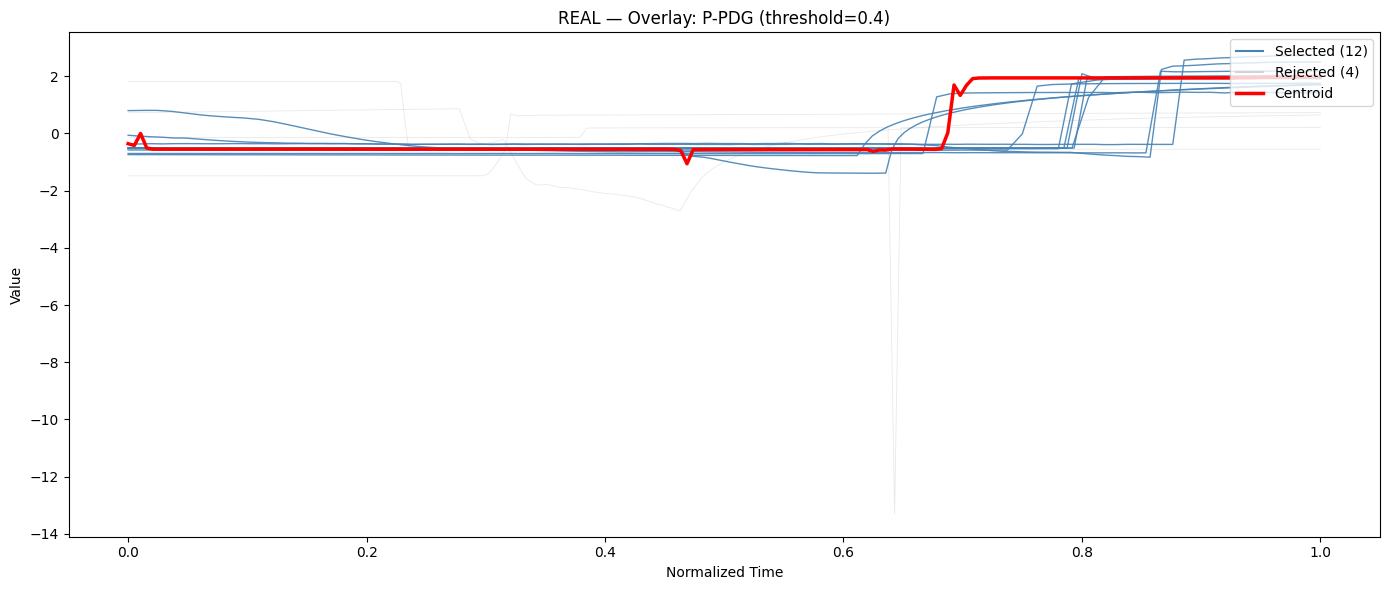

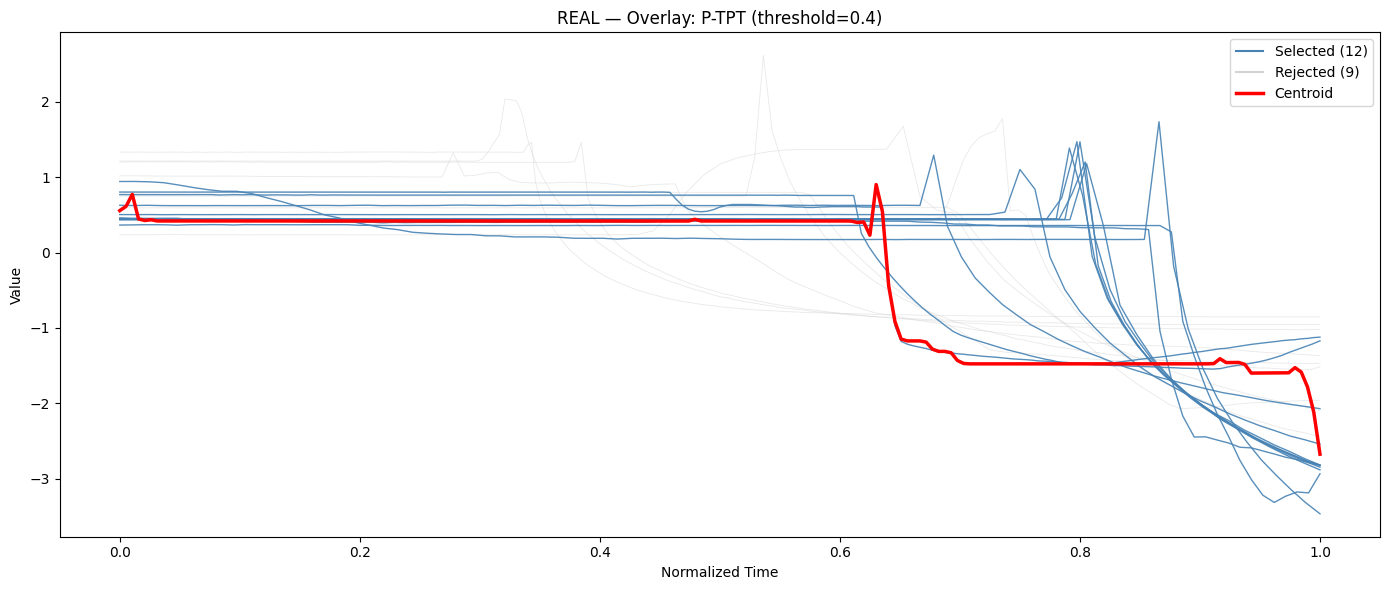

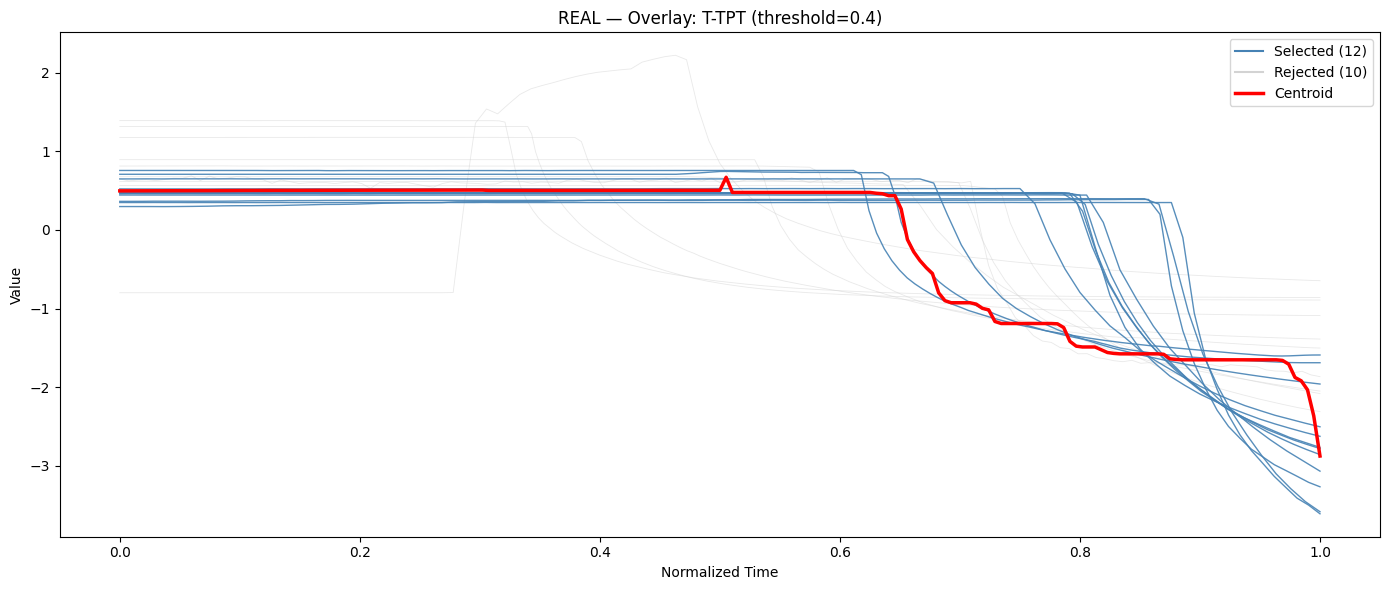

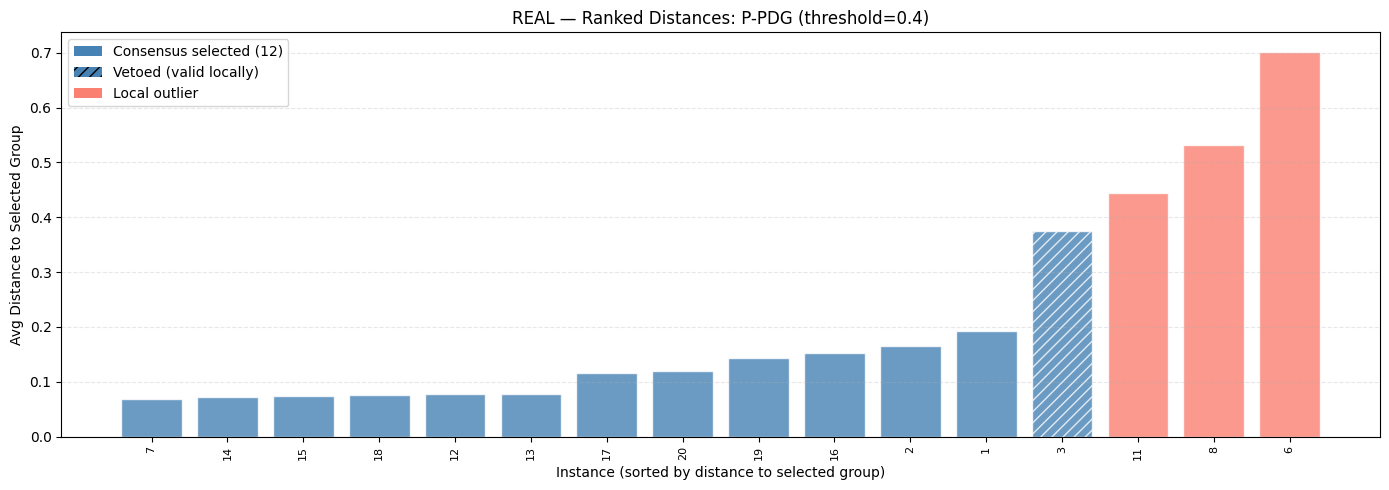

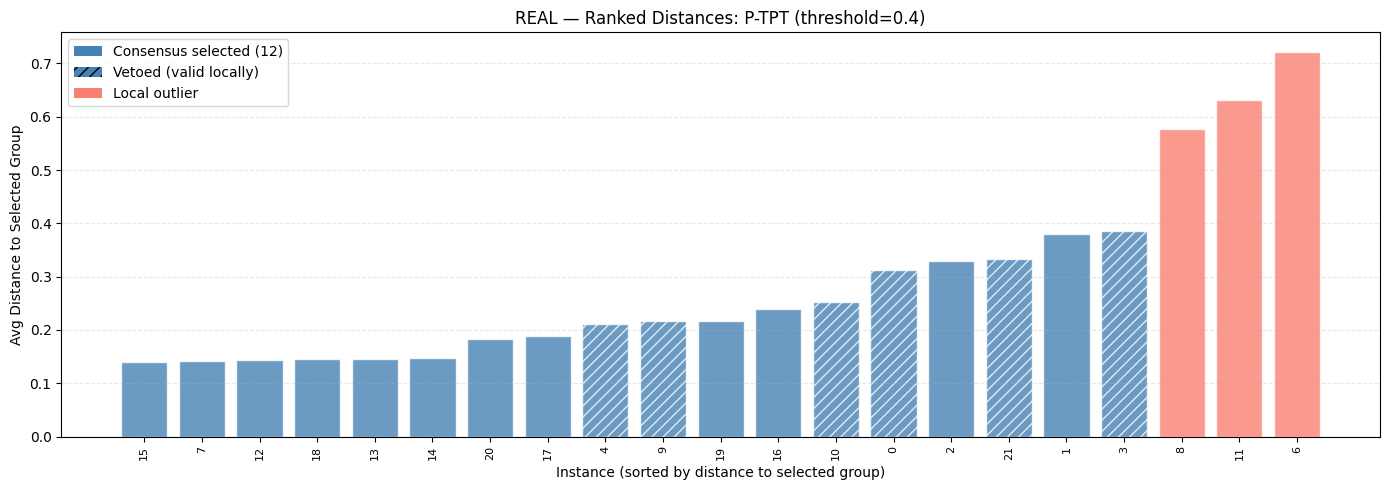

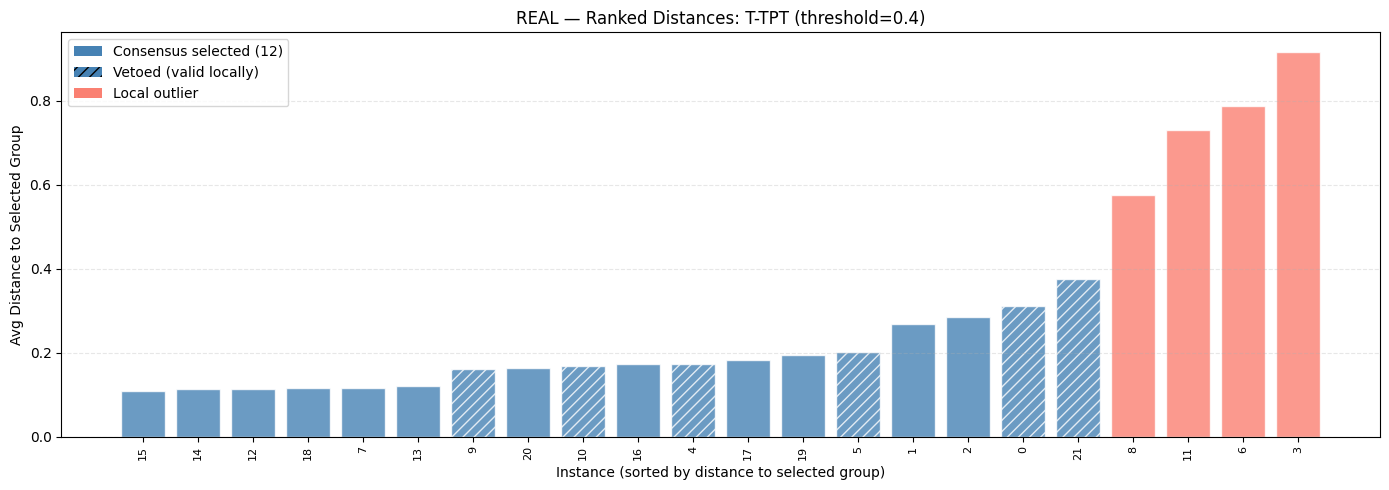

In [4]:
ds_real = ParquetDataset(ParquetDatasetConfig(
    path=DATASET_PATH,
    event_type=[EventPrefixEnum.REAL],
    target_class=[TARGET_CLASS],
))
data_real = ds_real.load_instances_by_variable(variables=TARGET_VARS)
print(f"Real: {len(ds_real)} instances")

run_analysis_pipeline(data_real, "REAL", exclude_vars=["P-MON-CKP"])

## Analysis 2: Simulated Data

Load only simulated events for class 2. Simulated data tends to be cleaner (no sensor noise or freezing), but cluster structure may differ significantly from real operational behavior.

[ParquetDataset] Dataset found at ../../dataset
[ParquetDataset] Validating dataset integrity...
[ParquetDataset] Dataset integrity check passed!
Simulated: 16 instances


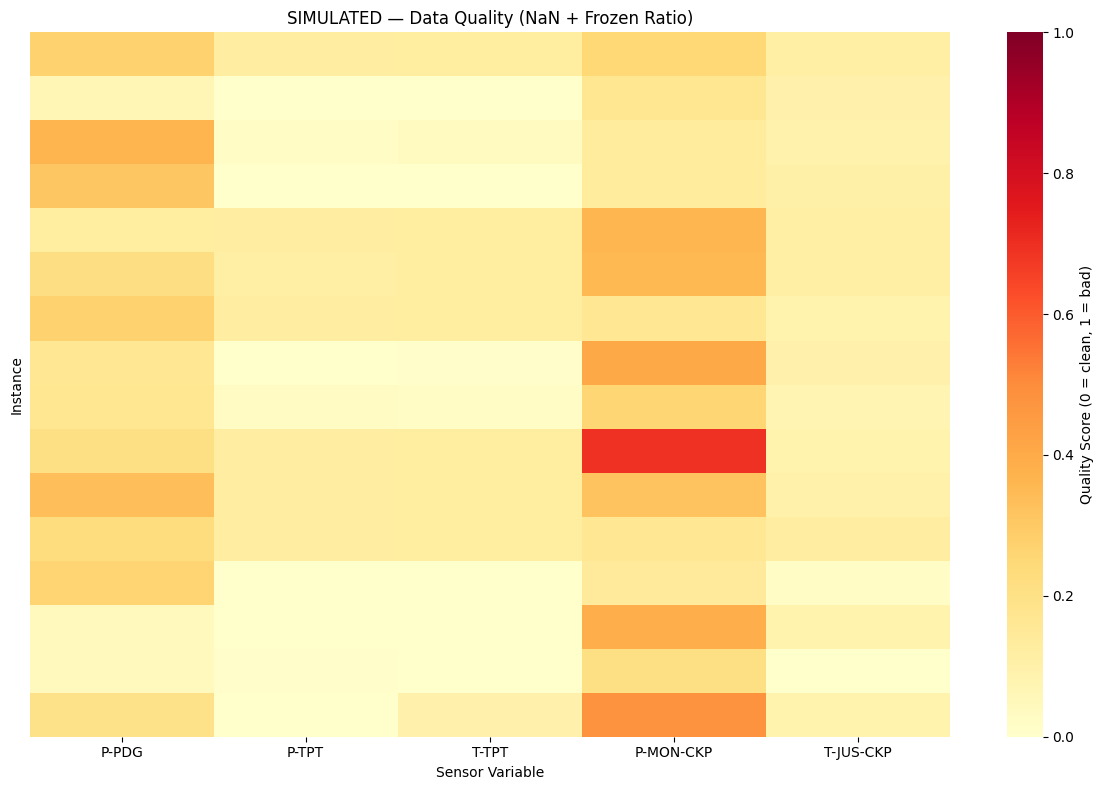

  Processing P-PDG... kept 16 instances
  Processing P-TPT... kept 16 instances
  T-TPT: excluded
  Processing P-MON-CKP... kept 16 instances
  Processing T-JUS-CKP... kept 16 instances

  Variables for consensus (4): ['P-PDG', 'P-TPT', 'P-MON-CKP', 'T-JUS-CKP']
  Consensus selected 6 instances at threshold 0.4


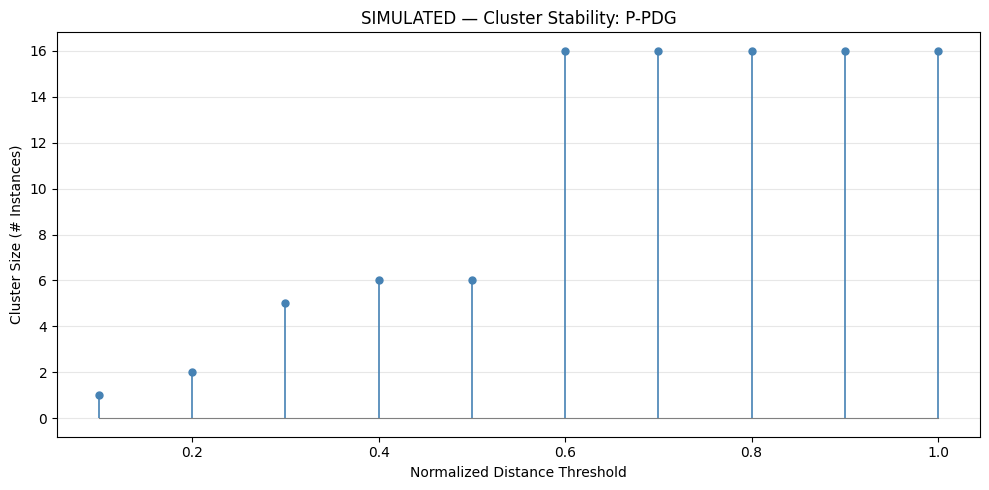

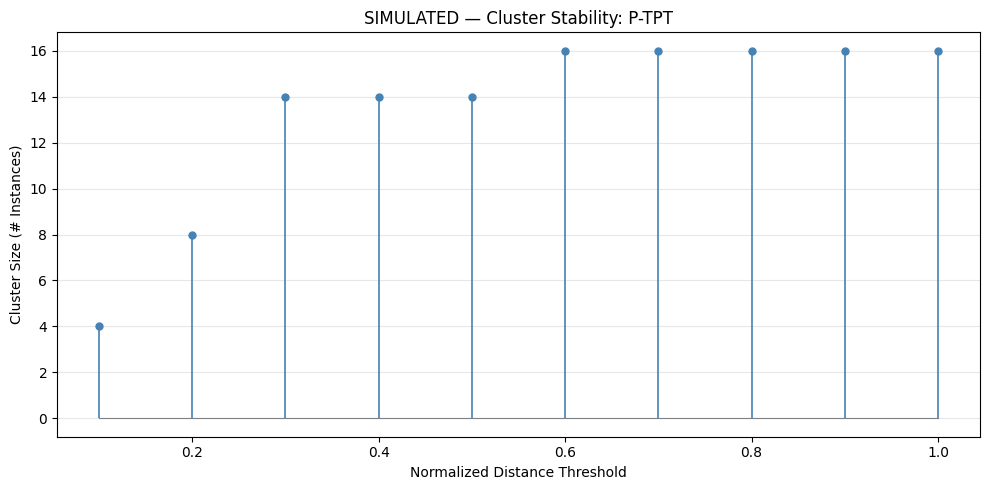

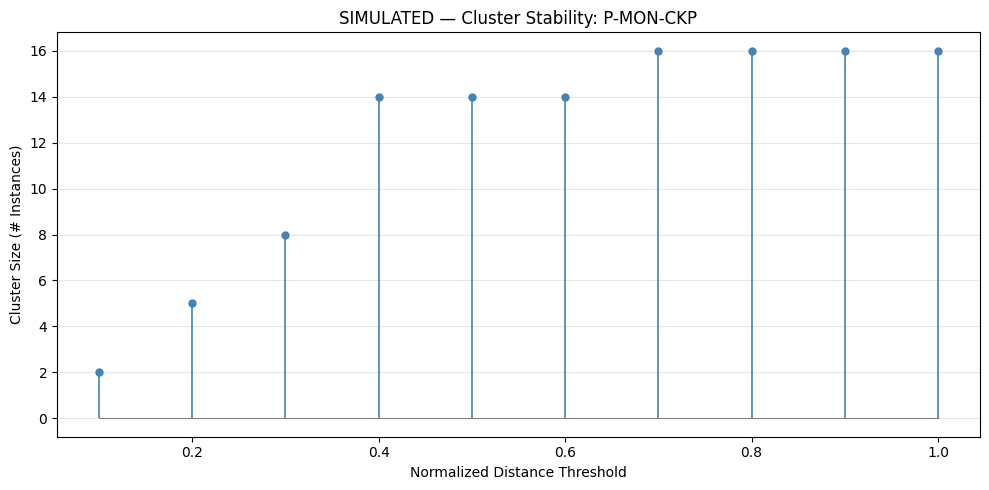

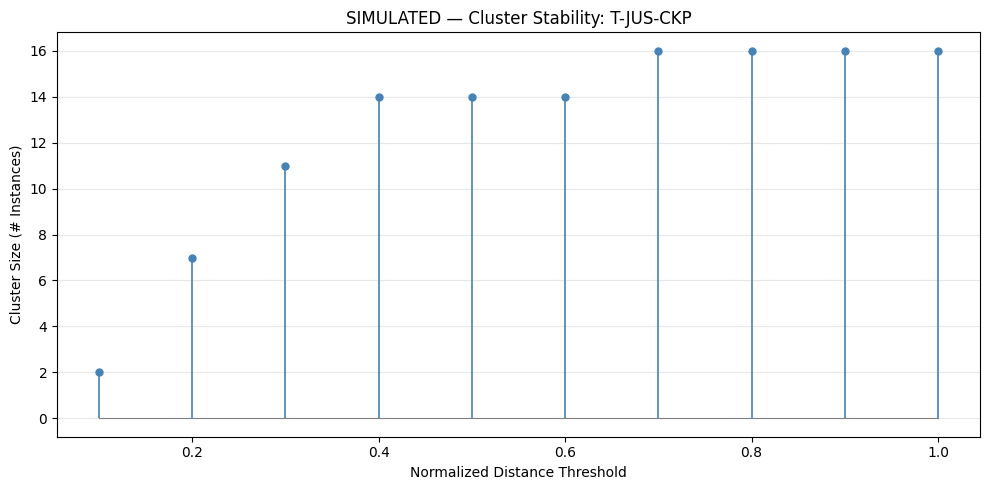

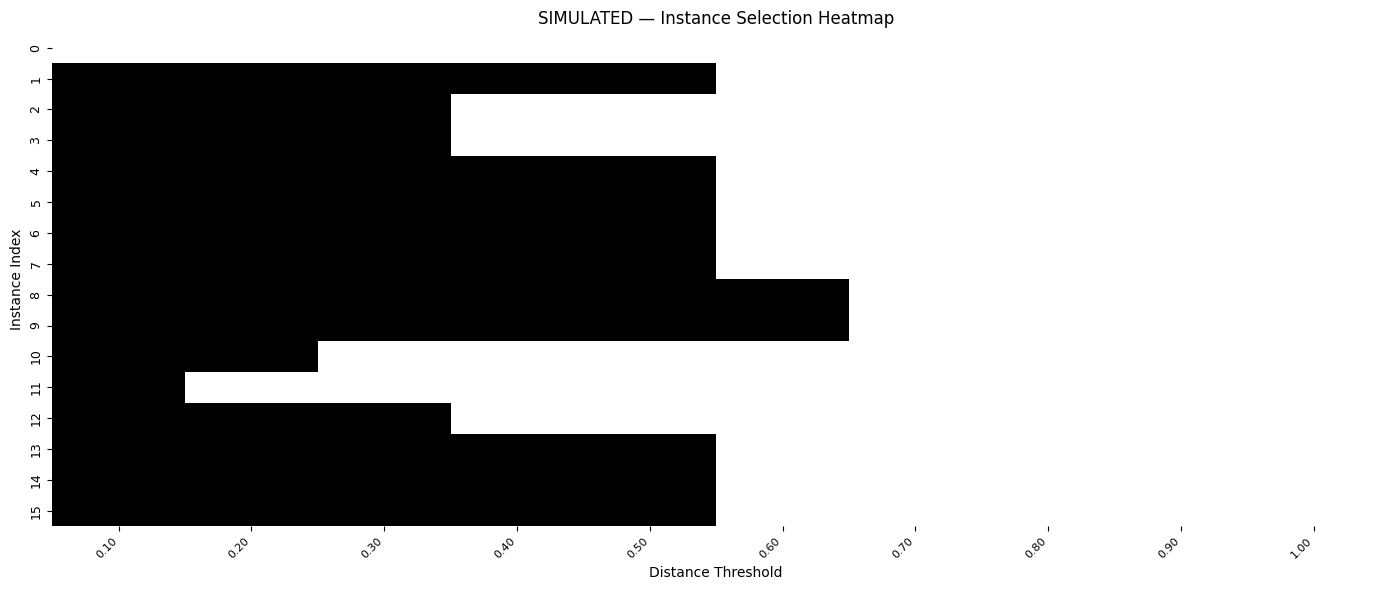

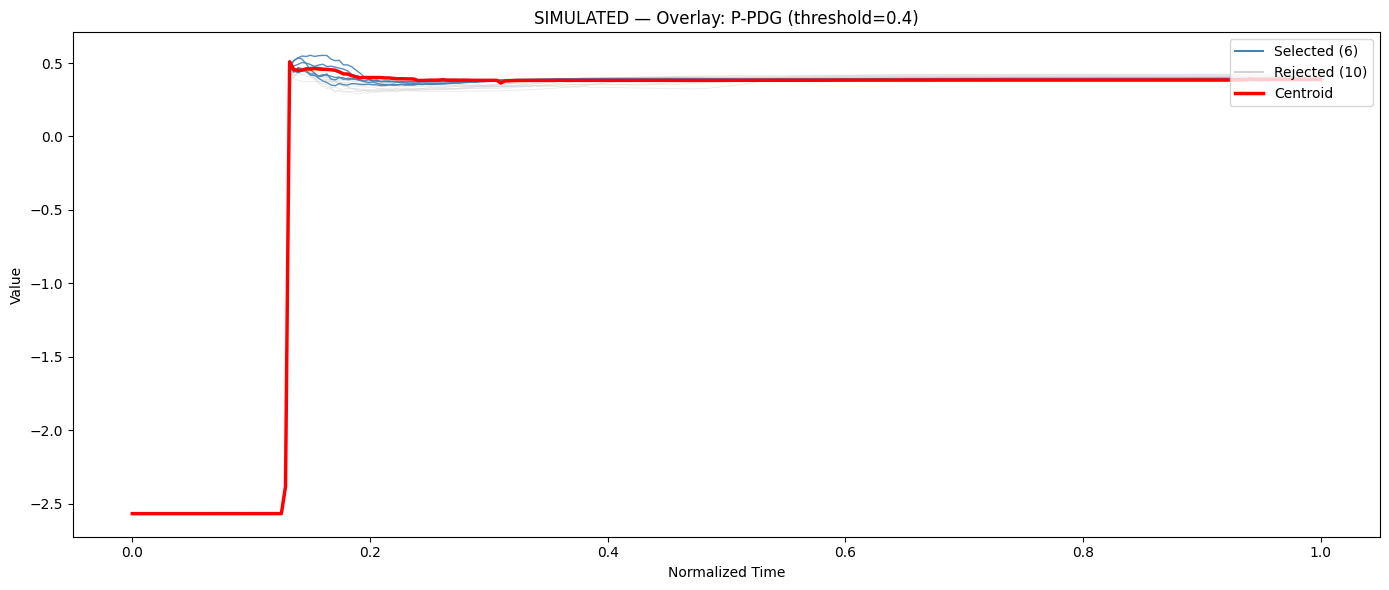

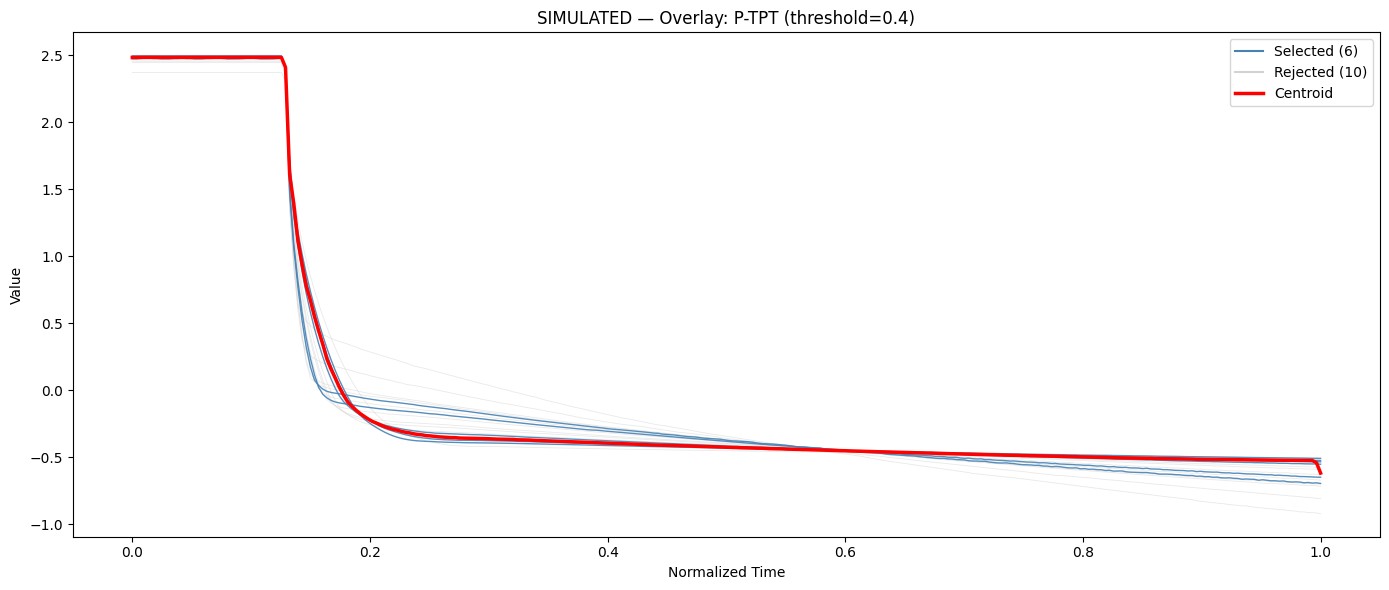

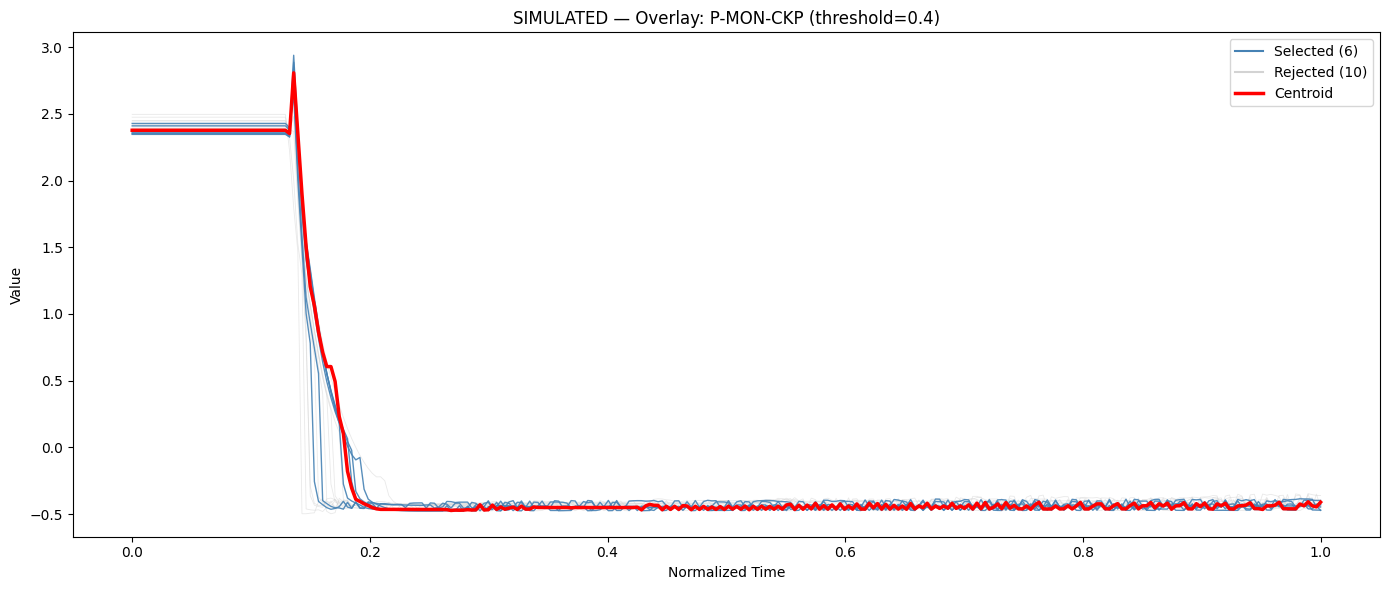

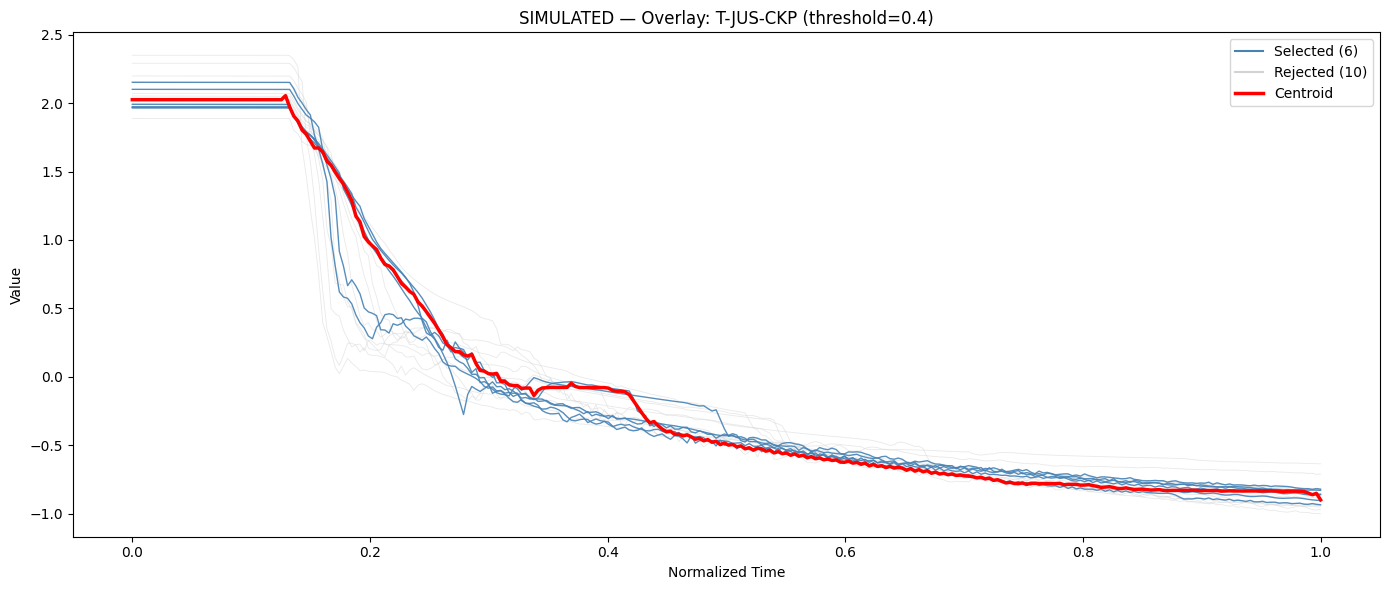

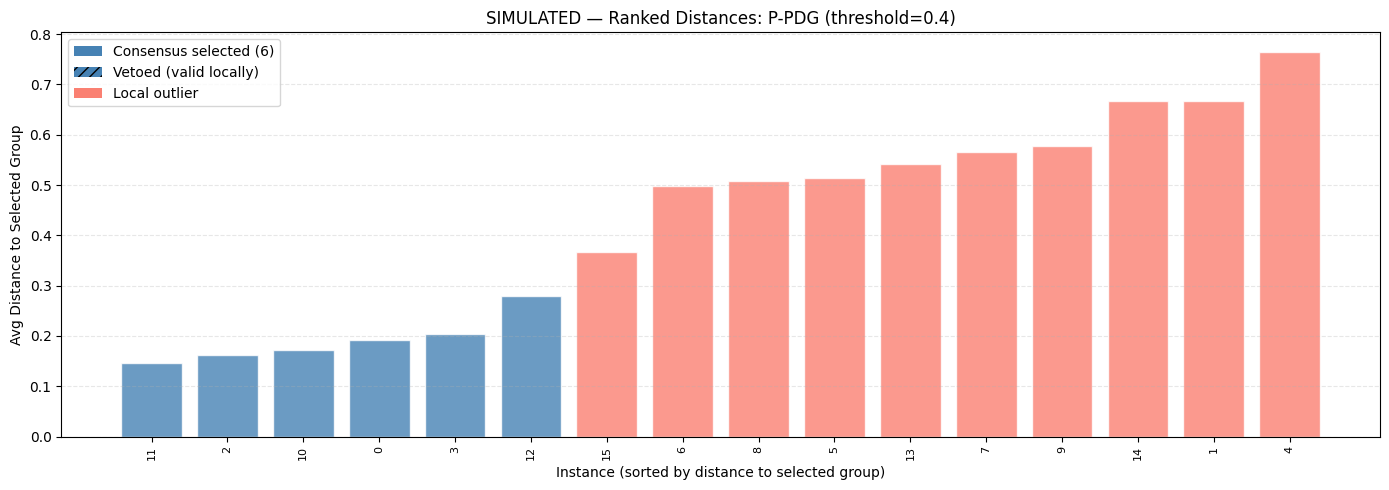

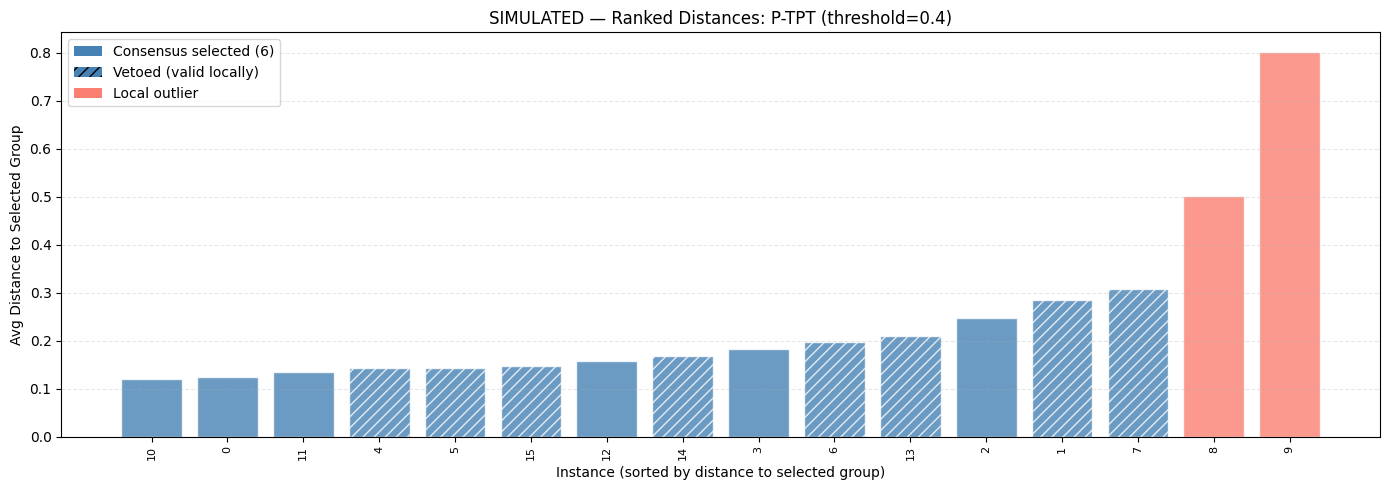

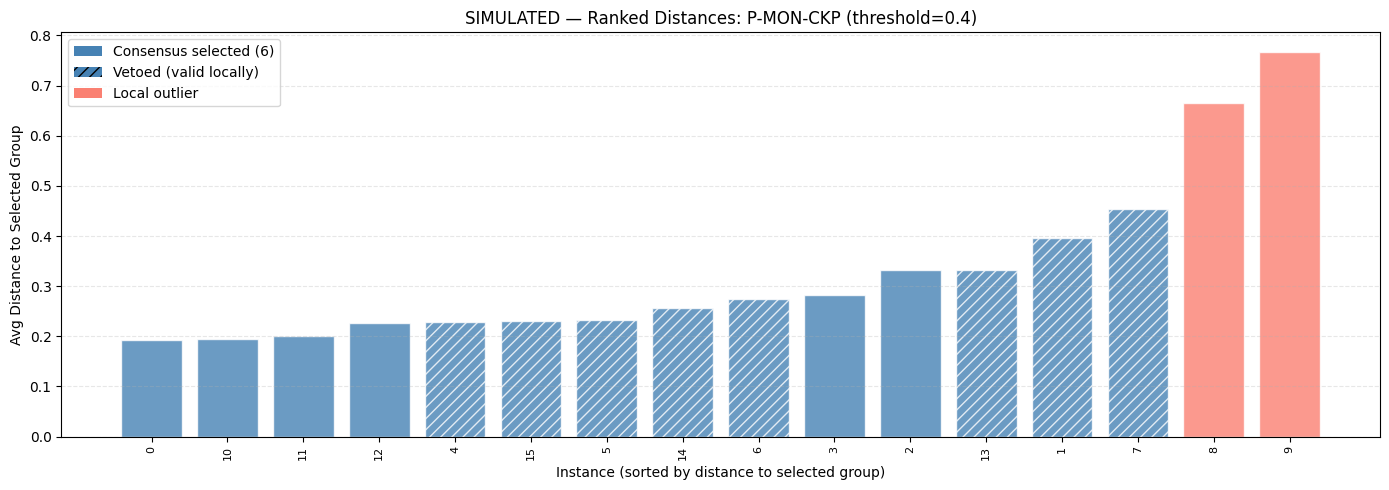

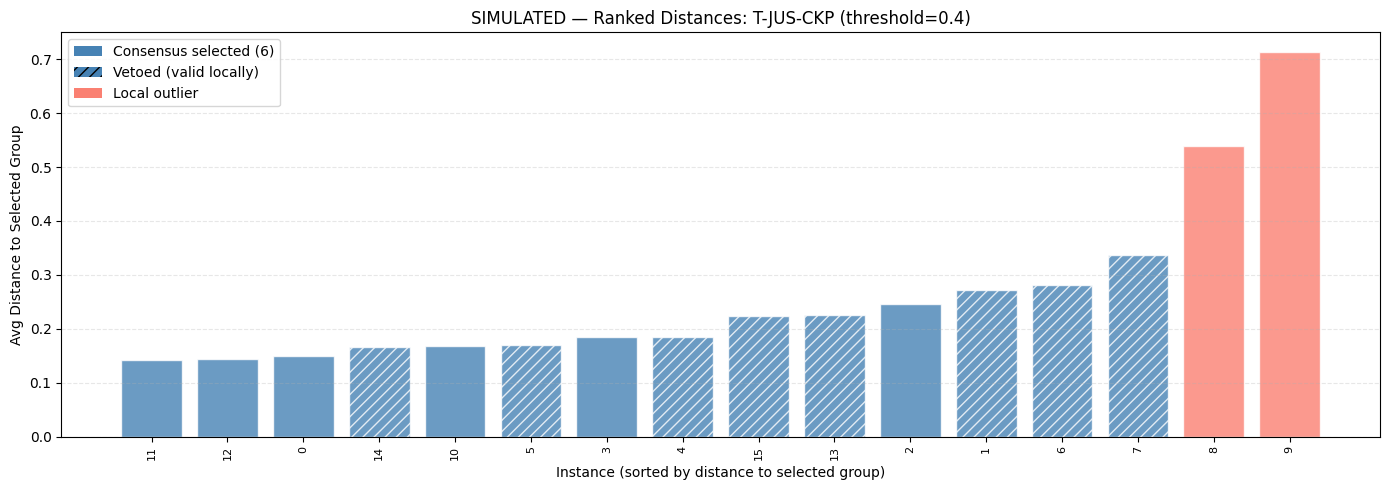

In [5]:
ds_sim = ParquetDataset(ParquetDatasetConfig(
    path=DATASET_PATH,
    event_type=[EventPrefixEnum.SIMULATED],
    target_class=[TARGET_CLASS],
))
data_sim = ds_sim.load_instances_by_variable(variables=TARGET_VARS)
print(f"Simulated: {len(ds_sim)} instances")

run_analysis_pipeline(data_sim, "SIMULATED", exclude_vars = ['T-TPT'])

## Analysis 3: Combined Data (Real + Simulated)

Mix both sources into a single dataset. The consensus pipeline will attempt to find instances that form a tight cluster across **all** variables, regardless of origin.

[ParquetDataset] Dataset found at ../../dataset
[ParquetDataset] Validating dataset integrity...
[ParquetDataset] Dataset integrity check passed!
Combined: 38 instances


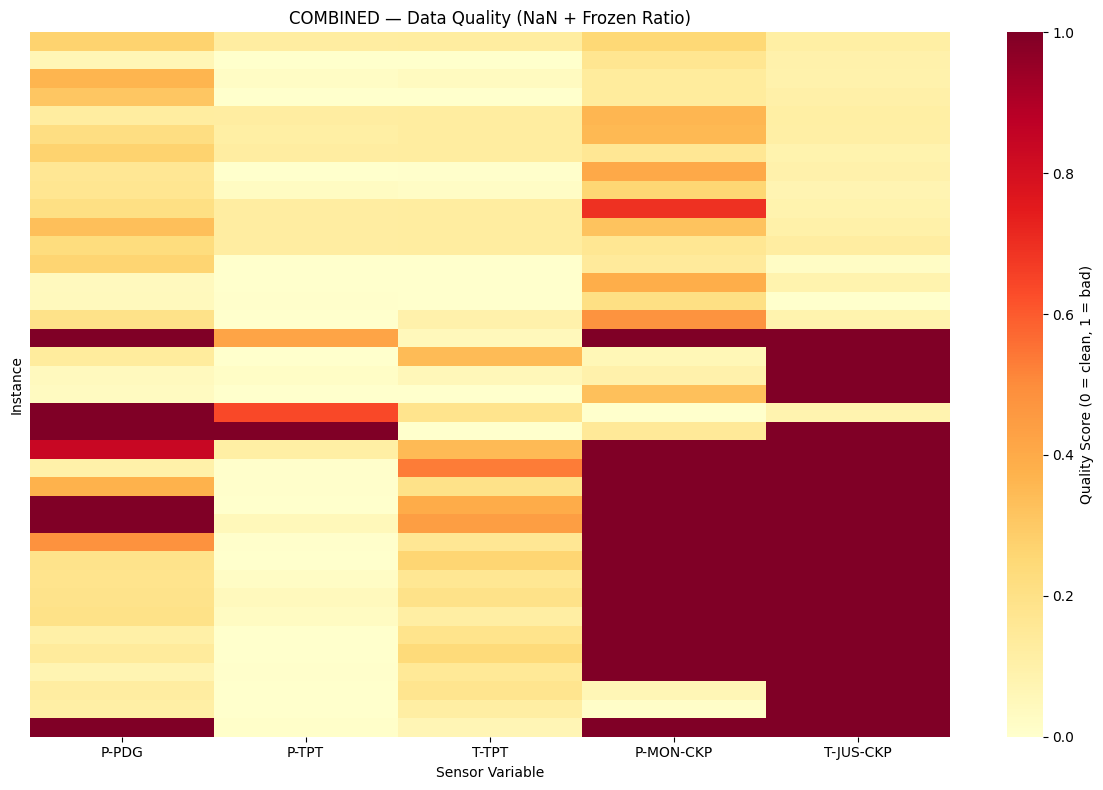

  Processing P-PDG... kept 32 instances
  Processing P-TPT... kept 37 instances
  Processing T-TPT... kept 38 instances
  Processing P-MON-CKP... kept 23 instances
  Processing T-JUS-CKP... kept 17 instances

  Variables for consensus (5): ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP']
  Consensus selected 16 instances at threshold 0.4


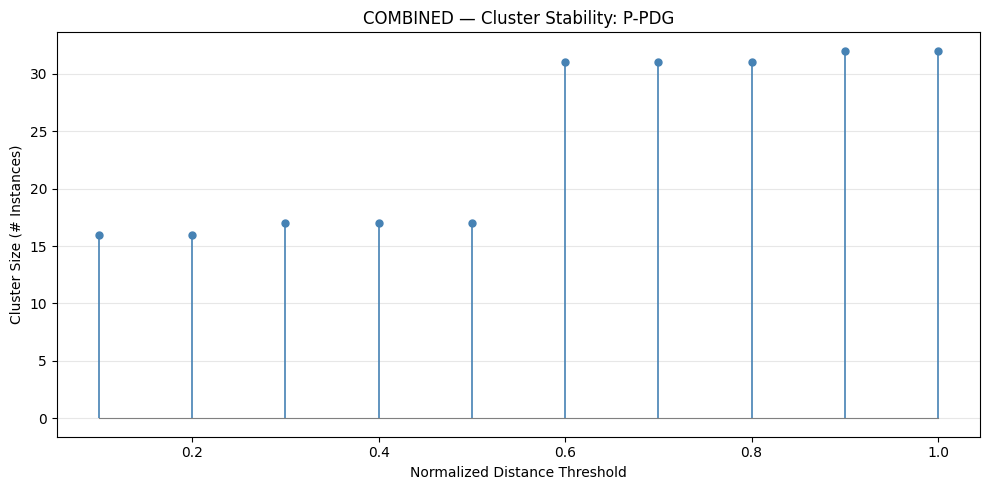

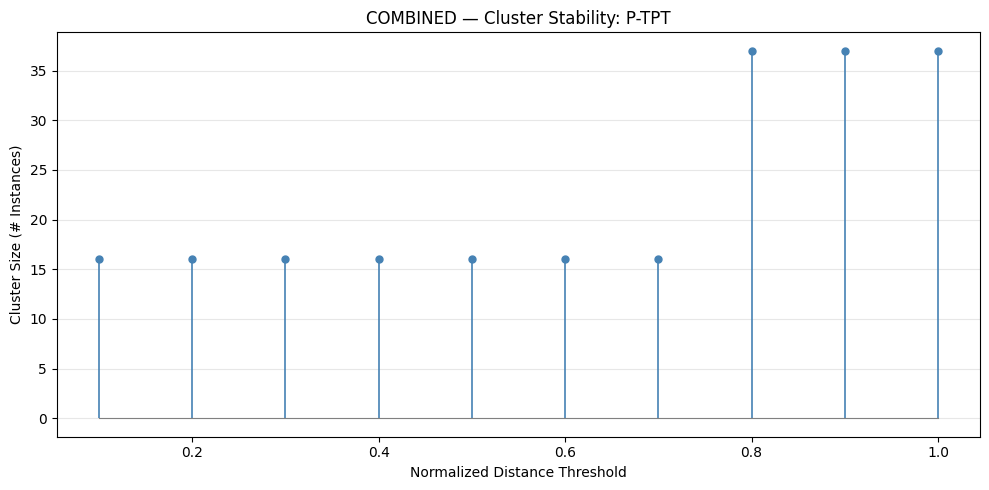

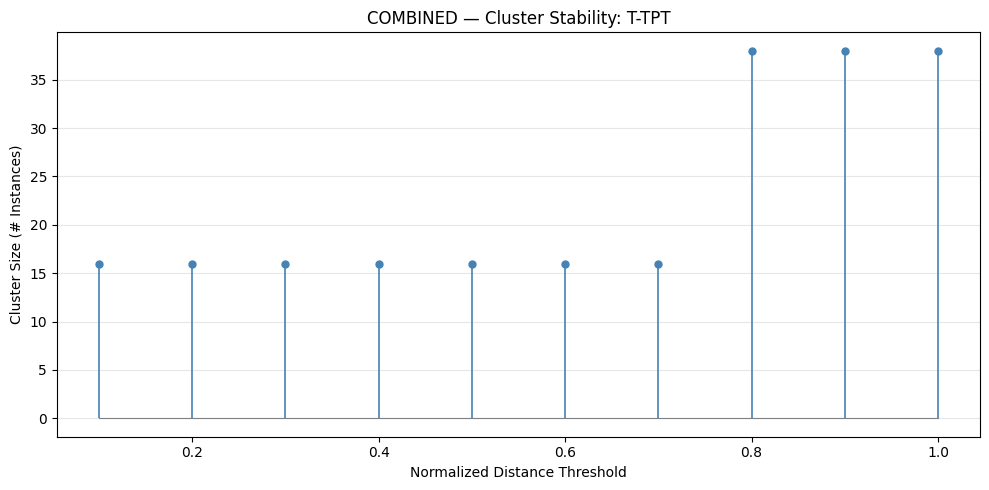

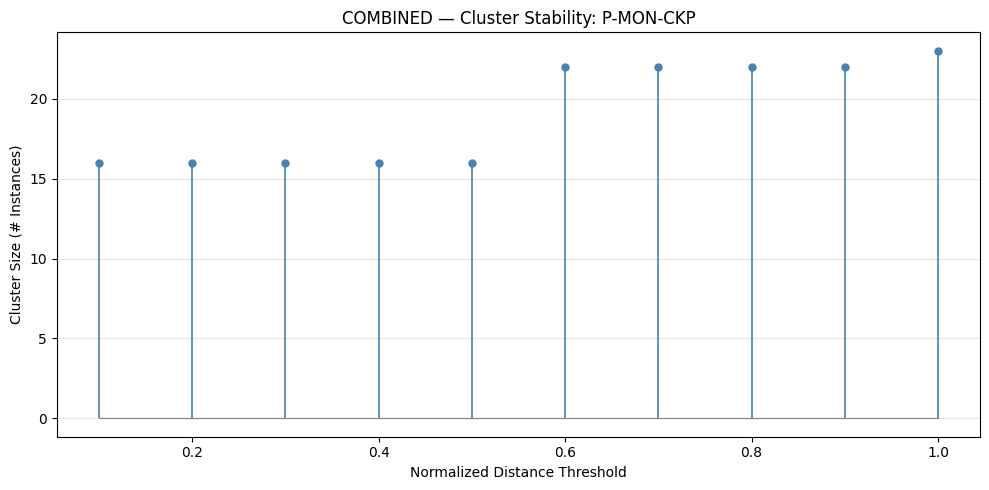

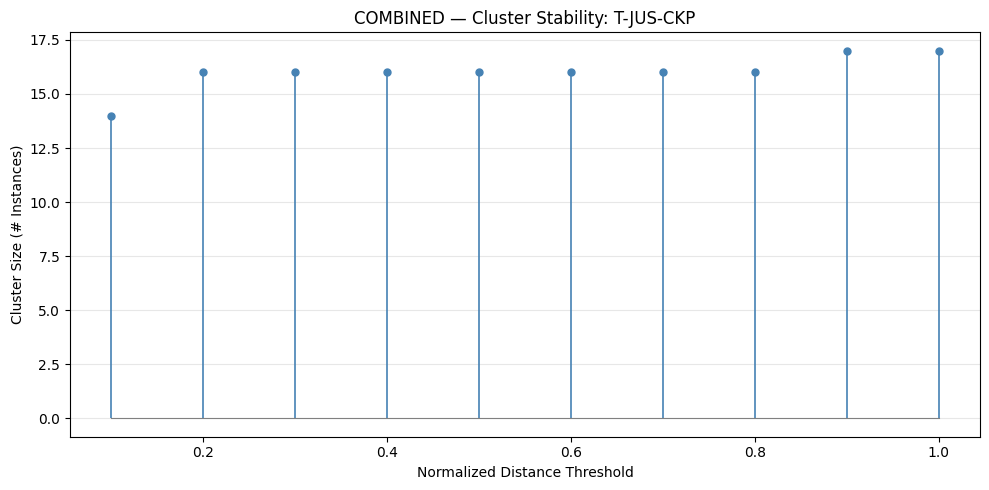

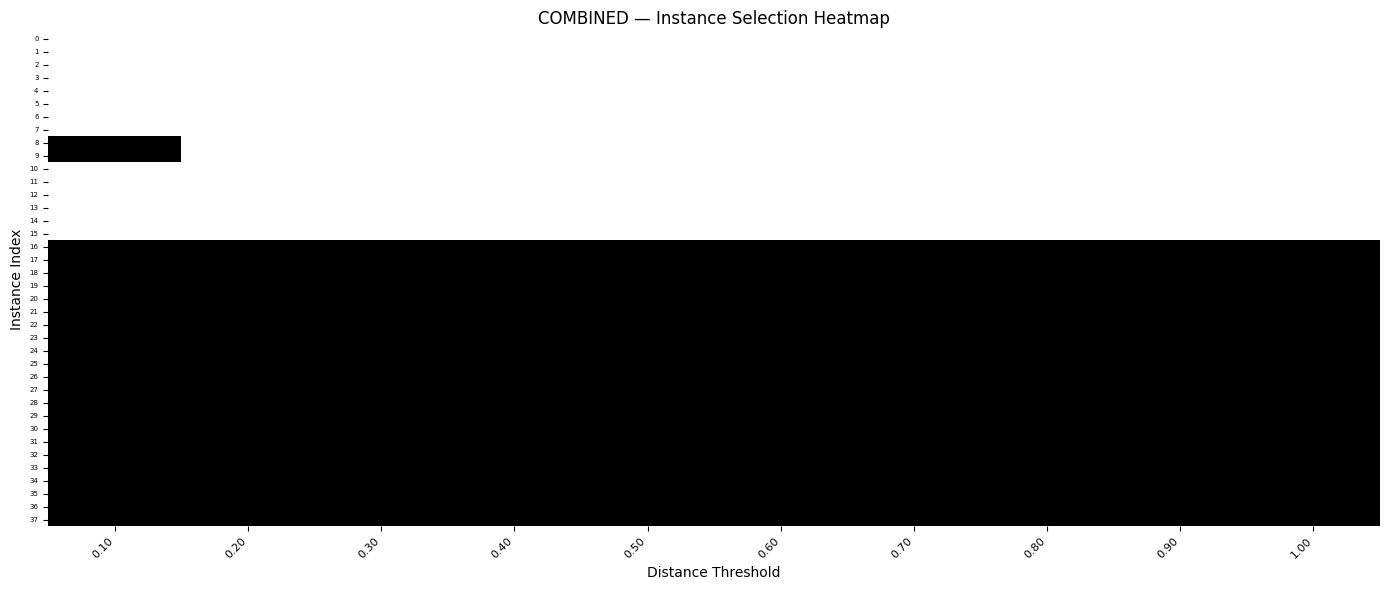

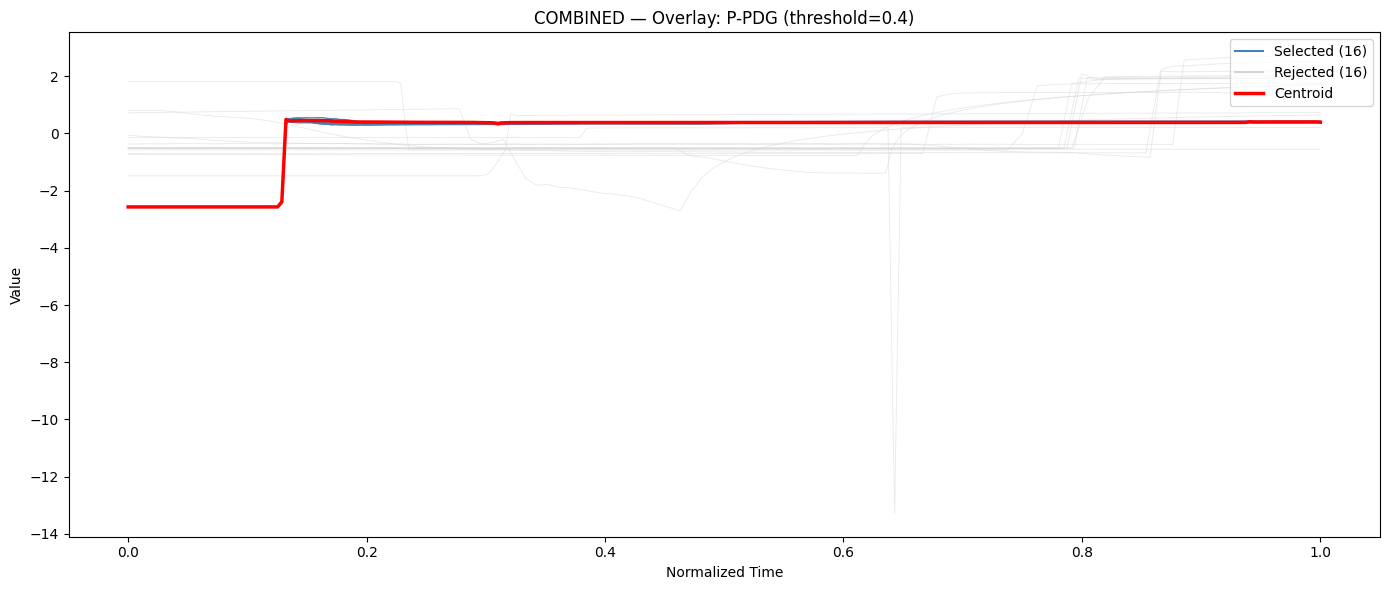

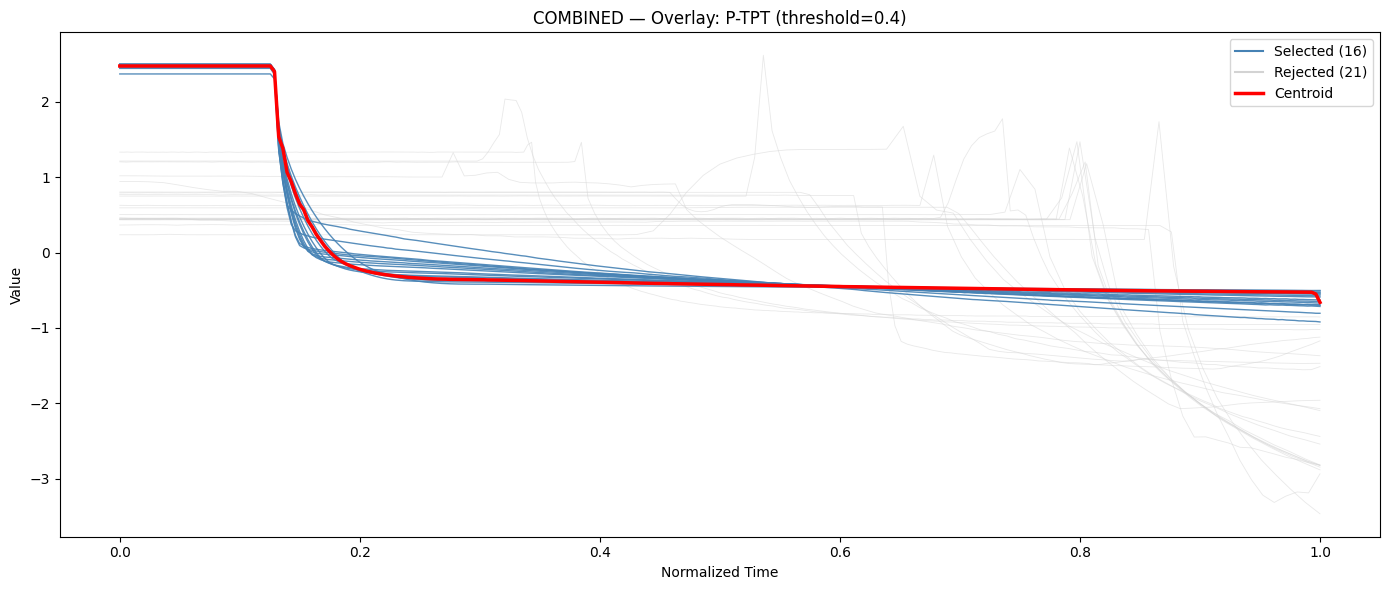

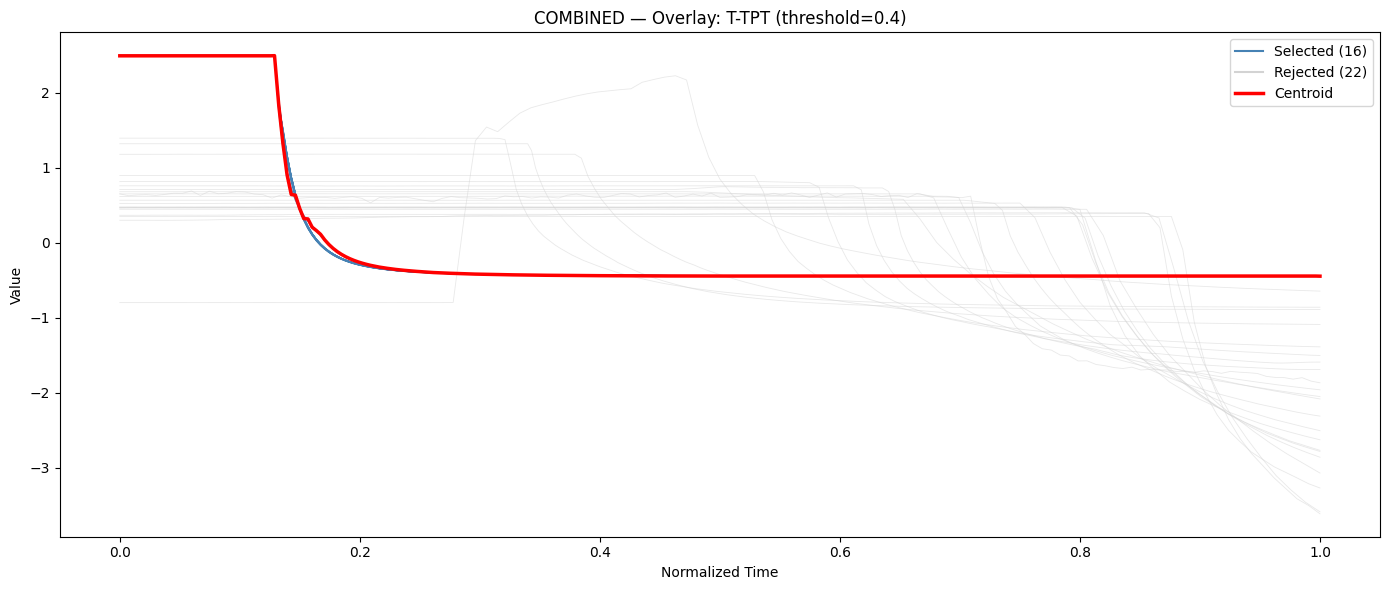

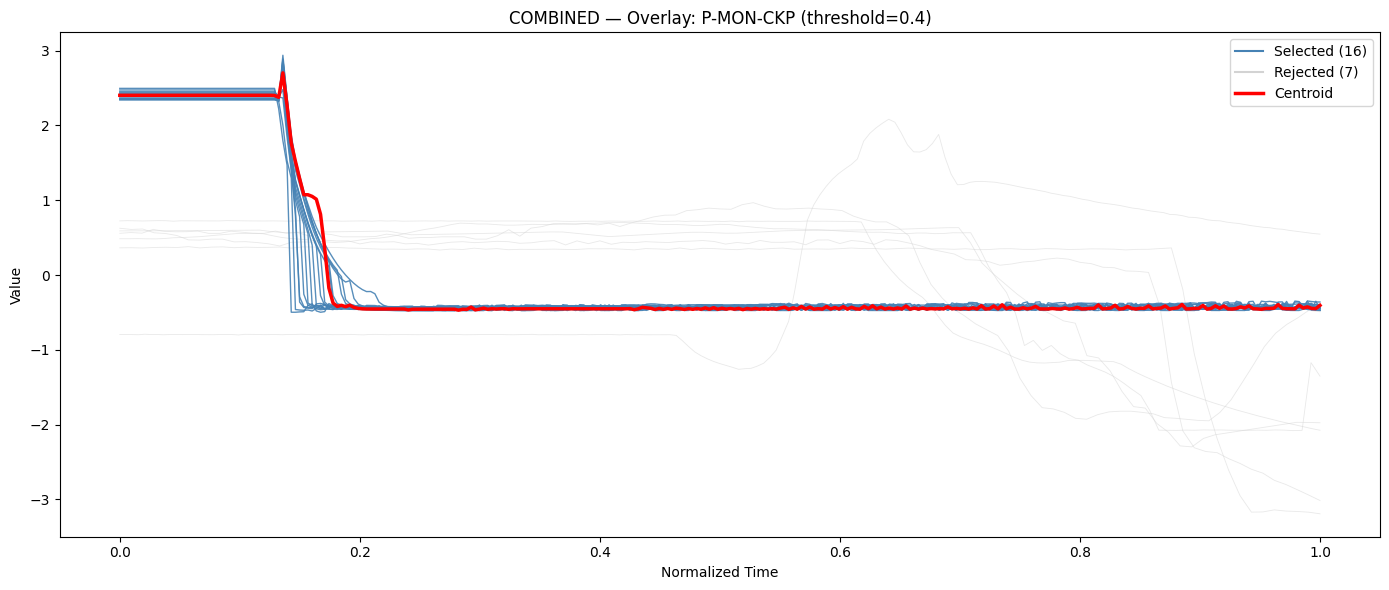

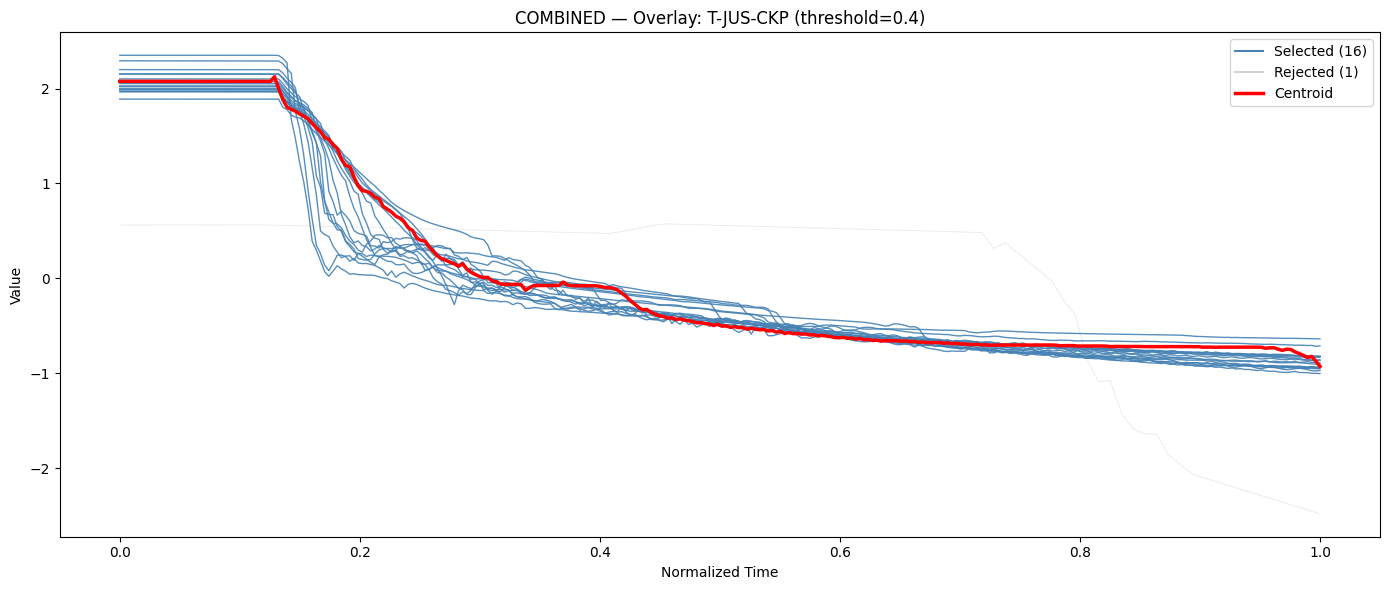

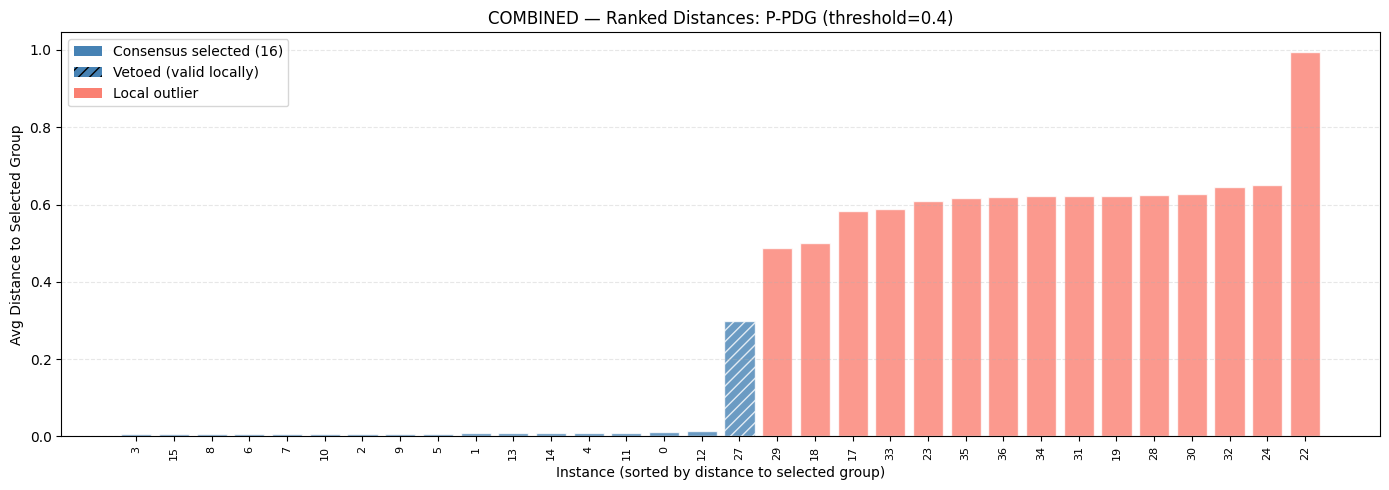

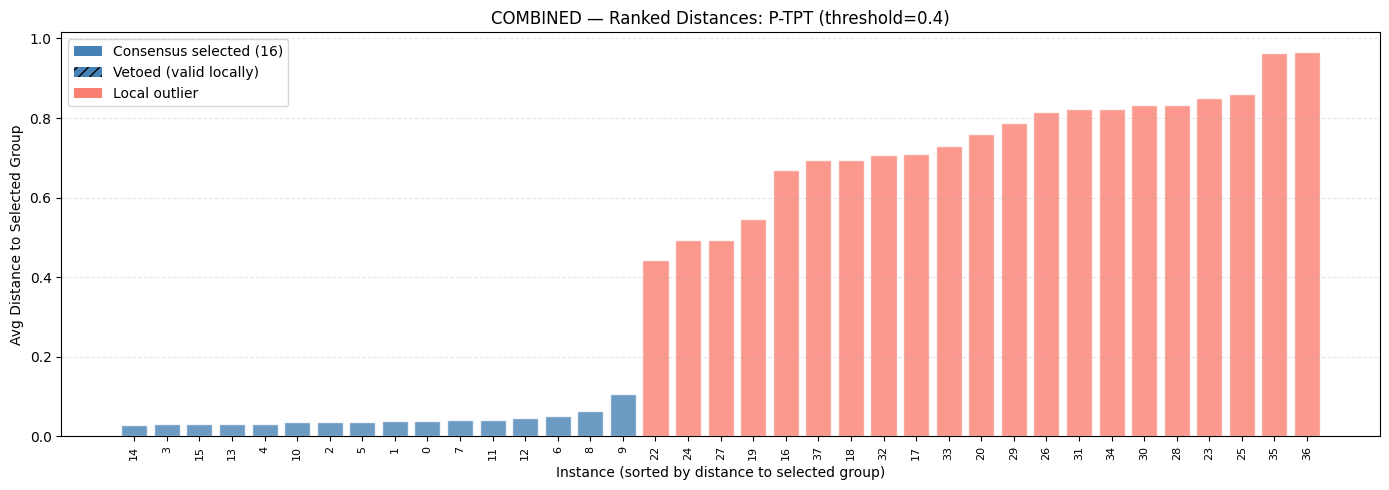

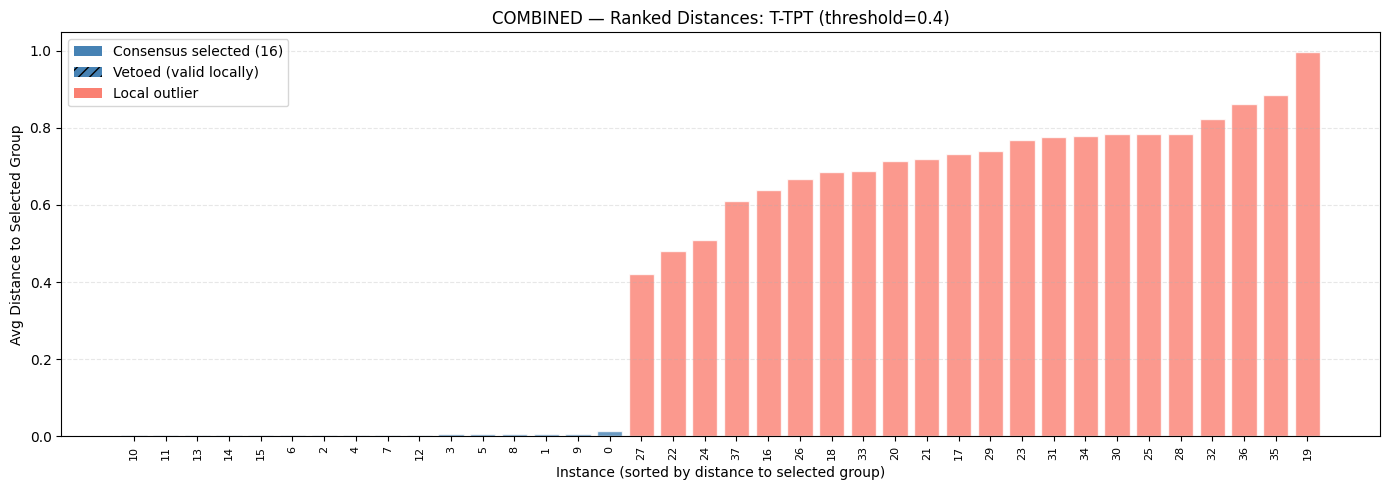

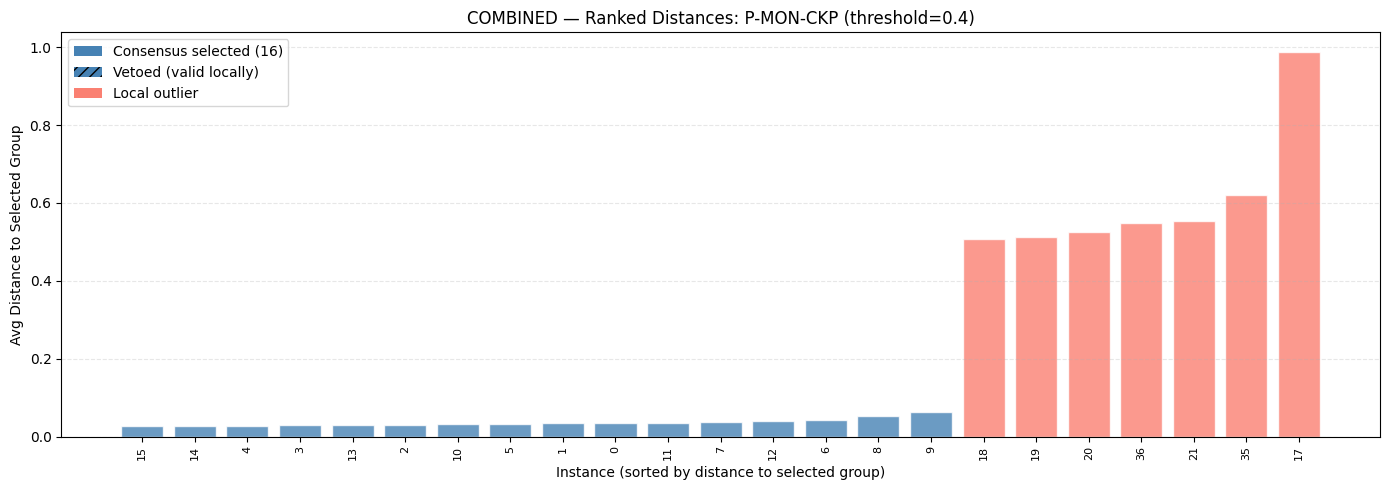

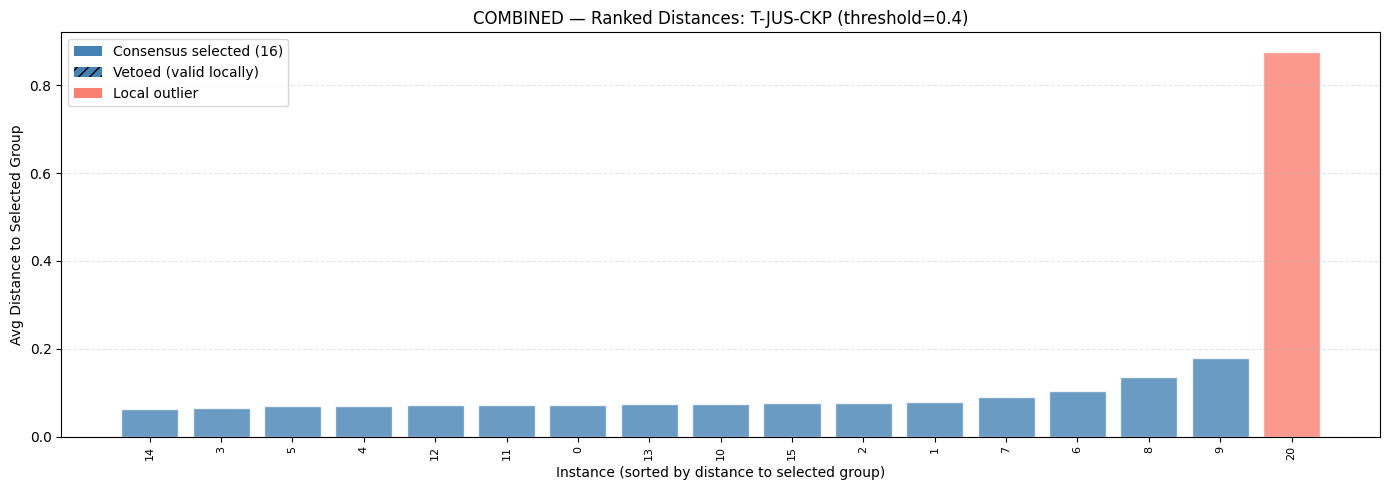

In [6]:
ds_combined = ParquetDataset(ParquetDatasetConfig(
    path=DATASET_PATH,
    event_type=[EventPrefixEnum.REAL, EventPrefixEnum.SIMULATED],
    target_class=[TARGET_CLASS],
))
data_combined = ds_combined.load_instances_by_variable(variables=TARGET_VARS)
print(f"Combined: {len(ds_combined)} instances")

run_analysis_pipeline(data_combined, "COMBINED")